# 📊 Daily Sales Forecasting with ARIMA Model 💣

## Business Problem Statement

A retail company records daily sales data for its stores. Management wants to:

* Understand sales patterns over time (trends, seasonality, short-term fluctuations).
* Forecast future sales to improve inventory planning, staff scheduling, and cash flow management.
* Evaluate forecast accuracy to decide if ARIMA is reliable for their planning, or if they should explore more advanced models.

**Key Question:** "Given historical daily sales, can we build a time series model that forecasts the next 14 days of sales with reasonable accuracy?"

---

## Time Series Forecasting on Daily Sales

1) **Load & clean data (dates, gaps, duplicates)**
2) **Visualize series + 7-day rolling trend**
3) **Stationarity check (ADF) and automatic differencing (d)**
4) **ACF/PACF plots + human-readable observations**
5) **Train/Test split**
6) **ARIMA model selection (small grid search on p,q; d fixed)**
7) **Forecast, evaluate (RMSE & MAPE), and plot results**
8) **Future forecast (next 14 days)**

In [2]:
#------------------------------------------------------
# SECTION 1: Imports & Settings
#-----------------------------------------------------

import warnings
warnings.filterwarnings("ignore") #Keep the output tidy for class

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [3]:
# Make plots look decent for look
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# ------------------------------------
# SECTION 2: Load the dataset (CSV)
# ------------------------------------
# NOTE: Update the path if your file is elsewhere.
CSV_PATH = "dailysales.csv"

# We read only the needed columns and parse dates explicitly for clarity.
# If your date format is different, adjust 'format' below or set infer_datetime_format=True.

df_raw = pd.read_csv(
    CSV_PATH,
    usecols=["date", "sales"]
)
# Parse date column; format '%d-%b-%y' matches '01-Jan-18'. If unsure, use pd.to_datetime with infer.
try:
    df_raw["date"] = pd.to_datetime(df_raw["date"], format="%d-%b-%y")
except Exception:
    df_raw["date"] = pd.to_datetime(df_raw["date"], infer_datetime_format=True)


df_raw.head()

,date,sales
0,2018-01-01,477.0
1,2018-01-02,365.0
2,2018-01-03,442.0
3,2018-01-04,490.0
4,2018-01-05,396.0


In [4]:
# -------------------------------------------
# SECTION 3: Basic Cleaning & Quality Checks
# -------------------------------------------
# Sort by date and drop exact duplicate rows (if any)
df_raw = df_raw.sort_values("date").drop_duplicates(subset=["date"], keep="last")

# keep='first' (default) → keeps the first occurrence of the duplicate row and drops the rest.

# keep='last' → keeps the last occurrence of the duplicate row and drops the earlier ones.

# keep=False → drops all occurrences of the duplicates (nothing is kept).



ts = df_raw.set_index("date")["sales"].astype("float64")

# Create a time series of sales with 'date' as index and values as float


In [5]:
ts.index.max()

Timestamp('2019-12-31 00:00:00')

In [6]:
full_index = pd.date_range(ts.index.min(), ts.index.max(), freq="D")  
full_index

DatetimeIndex(['2018-01-01', '2018-01-02', '2018-01-03', '2018-01-04',
               '2018-01-05', '2018-01-06', '2018-01-07', '2018-01-08',
               '2018-01-09', '2018-01-10',
               ...
               '2019-12-22', '2019-12-23', '2019-12-24', '2019-12-25',
               '2019-12-26', '2019-12-27', '2019-12-28', '2019-12-29',
               '2019-12-30', '2019-12-31'],
              dtype='datetime64[ns]', length=730, freq='D')

In [7]:
# Create a complete daily date range from min to max date
ts = ts.reindex(full_index)  
# Reindex time series to include all dates (fill missing dates with NaN)
ts

2018-01-01    477.0
2018-01-02    365.0
2018-01-03    442.0
2018-01-04    490.0
2018-01-05    396.0
              ...  
2019-12-27    133.0
2019-12-28    214.1
2019-12-29     85.5
2019-12-30    182.9
2019-12-31    322.7
Freq: D, Name: sales, Length: 730, dtype: float64

In [8]:
missing_days = ts.isna().sum()
missing_days

np.int64(27)

In [9]:
# Report missing days and fill them (for teaching simplicity we use linear interpolation)

print(f"Data span: {ts.index.min().date()} to {ts.index.max().date()} ({len(ts)} days)")

print(f"Missing days found and interpolated: {missing_days}")

ts = ts.interpolate(method="time")

# Fill missing values in the time series using time-based linear interpolation


Data span: 2018-01-01 to 2019-12-31 (730 days)
Missing days found and interpolated: 27


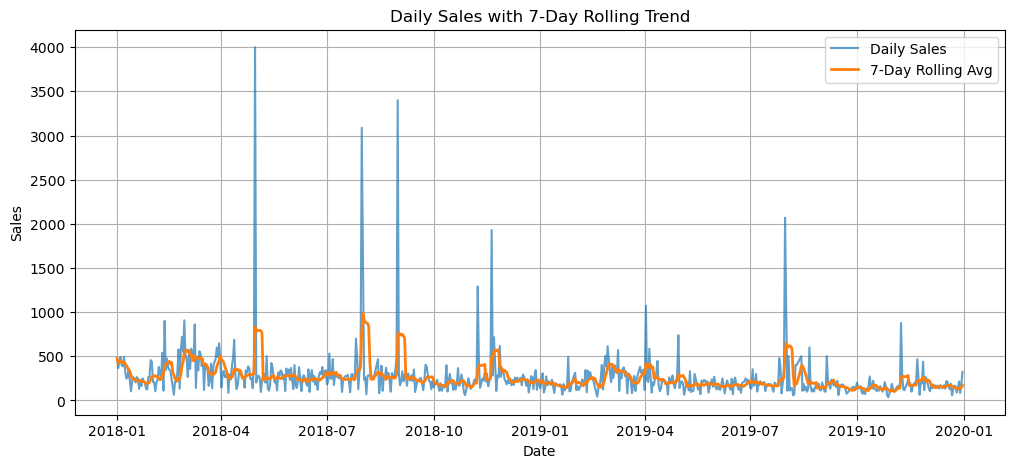

In [10]:

# --------------------------------------
# SECTION 4: Visualize Series & Trend
# --------------------------------------
plt.figure()
plt.plot(ts.index, ts.values, label="Daily Sales", alpha=0.7)

plt.plot(ts.index, ts.rolling(window=7, min_periods=1).mean().values,
         label="7-Day Rolling Avg", linewidth=2)
plt.title("Daily Sales with 7-Day Rolling Trend")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.legend()
plt.show()


In [11]:

# --------------------------------------------------------
# SECTION 5: Stationarity Check (ADF) and Differencing (d)
# --------------------------------------------------------
def adf_summary(series, label="Series"):
    """Run ADF test and print a friendly summary."""
    result = adfuller(series.dropna(), autolag="AIC")
    
    adf_stat, pvalue = result[0], result[1]
    print(f"\nADF Test on {label}:")
    print(f"  ADF Statistic = {adf_stat:.3f}")
    print(f"  p-value       = {pvalue:.4f}")
    print("  Interpretation:",
          "Stationary ✅ (reject H0)" if pvalue <= 0.05 else "Non-stationary ❌ (fail to reject H0)")
    return pvalue

# Automatically choose minimal differencing d ∈ {0,1,2} to reach stationarity
d = 0
pval0 = adf_summary(ts, "Original series")
if pval0 > 0.05:
    d = 1
    pval1 = adf_summary(ts.diff(1), "1st difference")
    if pval1 > 0.05:
        d = 2
        pval2 = adf_summary(ts.diff(2), "2nd difference")

print(f"\nChosen differencing order d = {d}")

# This is the series we'll use for ACF/PACF inspection
ts_for_plots = ts if d == 0 else ts.diff(d)
ts_for_plots = ts_for_plots.dropna()




ADF Test on Original series:
  ADF Statistic = -21.634
  p-value       = 0.0000
  Interpretation: Stationary ✅ (reject H0)

Chosen differencing order d = 0


In [12]:
max_lags = min(40, len(ts_for_plots) // 3)  # safe bound for short series
max_lags

40

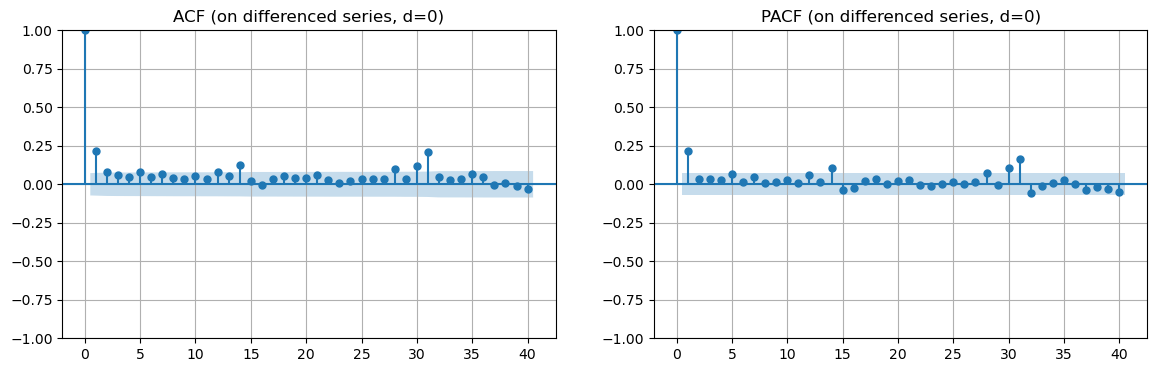


--- ACF/PACF Observations (talking points for class) ---
Significant ACF lags (first 40 checked): []
Significant PACF lags (first 40 checked): []
No strong weekly seasonal spikes detected in ACF.
PACF suggests AR component up to ~0 (cutoff behavior).
ACF suggests MA component up to ~0 (cutoff behavior).
We will still confirm p & q via a small AIC-based grid search.


In [13]:
# --------------------------------------------------------
# SECTION 6: ACF & PACF 
# --------------------------------------------------------
# Plot the ACF/PACF for visual teaching
max_lags = min(40, len(ts_for_plots) // 3)  # safe bound for short series

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_for_plots, lags=max_lags, ax=axes[0])
plot_pacf(ts_for_plots, lags=max_lags, ax=axes[1])
axes[0].set_title(f"ACF (on differenced series, d={d})")
axes[1].set_title(f"PACF (on differenced series, d={d})")
plt.show()

# Compute significant lags programmatically (95% CI) for observations text
acf_vals, acf_ci = acf(ts_for_plots, nlags=max_lags, alpha=0.05, fft=True)
pacf_vals, pacf_ci = pacf(ts_for_plots, nlags=max_lags, alpha=0.05, method="ywmle")

def significant_lags(values, ci):
    sig = []
    for lag in range(1, len(values)):
        lower, upper = ci[lag]
        if values[lag] < lower or values[lag] > upper:
            sig.append(lag)
    return sig

acf_sig = significant_lags(acf_vals, acf_ci)
pacf_sig = significant_lags(pacf_vals, pacf_ci)

# Detect simple weekly seasonality clue (daily data): spikes near lag 7,14,21...
seasonal_flags = [lag for lag in acf_sig if lag % 7 == 0]

print("\n--- ACF/PACF Observations (talking points for class) ---")
print(f"Significant ACF lags (first {max_lags} checked): {acf_sig[:10]}{' ...' if len(acf_sig)>10 else ''}")
print(f"Significant PACF lags (first {max_lags} checked): {pacf_sig[:10]}{' ...' if len(pacf_sig)>10 else ''}")

# Heuristic suggestions:
def consecutive_head(lags):
    """Return length of the longest initial consecutive run starting at 1."""
    run = 0
    for k in range(1, 10):  # up to 9 for readability
        if k in lags:
            run += 1
        else:
            break
    return run

p_guess = consecutive_head(pacf_sig)  # AR order from PACF cutoff
q_guess = consecutive_head(acf_sig)   # MA order from ACF cutoff

if 7 in acf_sig or 14 in acf_sig or 21 in acf_sig:
    print("ACF shows spikes at multiples of 7 → possible weekly seasonality (consider SARIMA).")
else:
    print("No strong weekly seasonal spikes detected in ACF.")

print(f"PACF suggests AR component up to ~{p_guess} (cutoff behavior).")
print(f"ACF suggests MA component up to ~{q_guess} (cutoff behavior).")
print("We will still confirm p & q via a small AIC-based grid search.")



In [14]:
# --------------------------------------------------------
# SECTION 7: Train/Test Split
# --------------------------------------------------------
# Use the last ~20% (capped between 14 and 30 points) as test for evaluation
N = len(ts)
test_size = max(14, min(30, N // 5))
print('\n',N)
print('\n',test_size)
train = ts.iloc[:-test_size]
test = ts.iloc[-test_size:]

print(f"\nTrain size: {len(train)} points, Test size: {len(test)} points")



 730

 30

Train size: 700 points, Test size: 30 points


In [15]:

# --------------------------------------------------------
# SECTION 8: Model selection for (p,q) via small grid search
# --------------------------------------------------------
# We keep d fixed (from ADF). Try small values for p,q (0..3) to avoid overfitting.

pq_candidates = [(p, q) for p in range(0, 4) for q in range(0, 4)]

best_order = None
best_aic = np.inf
best_model = None

for p, q in pq_candidates:
    try:
        model = ARIMA(train, order=(p, d, q))
        fitted = model.fit()
        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_order = (p, d, q)
            best_model = fitted
    except Exception:
        # Some (p,q) combos can fail to converge; just skip them
        continue

print(f"\nBest ARIMA order by AIC on train: {best_order} (AIC={best_aic:.2f})")



C:\Users\C5144878\AppData\Local\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Best ARIMA order by AIC on train: (2, 0, 1) (AIC=9831.22)



Evaluation on Test Set:
  RMSE = 75.487
  MAPE = 54.62%


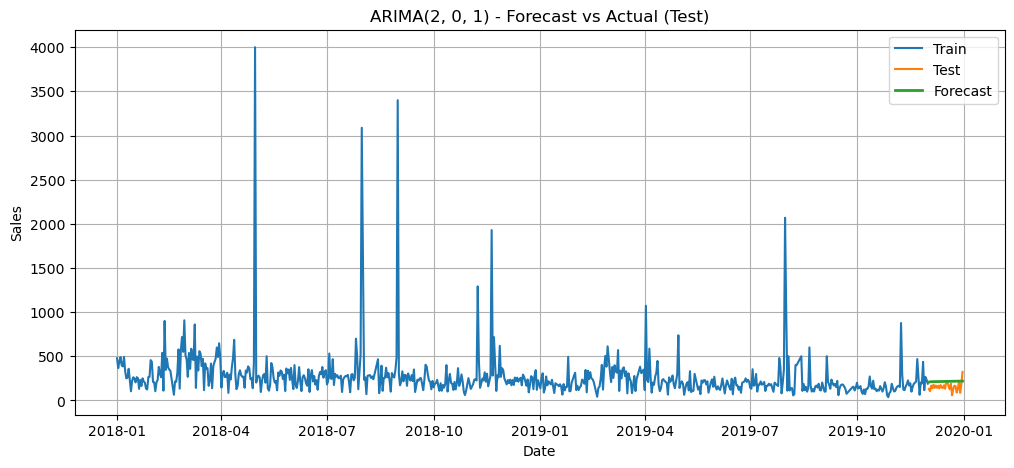

In [16]:
# --------------------------------------------------------
# SECTION 9: Forecast on the test set & evaluate
# --------------------------------------------------------
# Forecast exactly the test horizon
steps = len(test)
pred = best_model.forecast(steps=steps)
pred.index = test.index  # align for plotting

rmse = np.sqrt(mean_squared_error(test, pred))
mape = mean_absolute_percentage_error(test, pred) * 100

print("\nEvaluation on Test Set:")
print(f"  RMSE = {rmse:.3f}")
print(f"  MAPE = {mape:.2f}%")

# Plot Train/Test/Forecast for the audience
plt.figure()
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index, test.values, label="Test")
plt.plot(pred.index, pred.values, label="Forecast", linewidth=2)
plt.title(f"ARIMA{best_order} - Forecast vs Actual (Test)")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.legend()
plt.show()



Next 14 days forecast:
              forecast
2020-01-01  218.586796
2020-01-02  200.211985
2020-01-03  197.129187
2020-01-04  196.773251
2020-01-05  196.902999
2020-01-06  197.118686
2020-01-07  197.349015
2020-01-08  197.581271
2020-01-09  197.813187
2020-01-10  198.044364
2020-01-11  198.274731
2020-01-12  198.504279
2020-01-13  198.733008
2020-01-14  198.960921


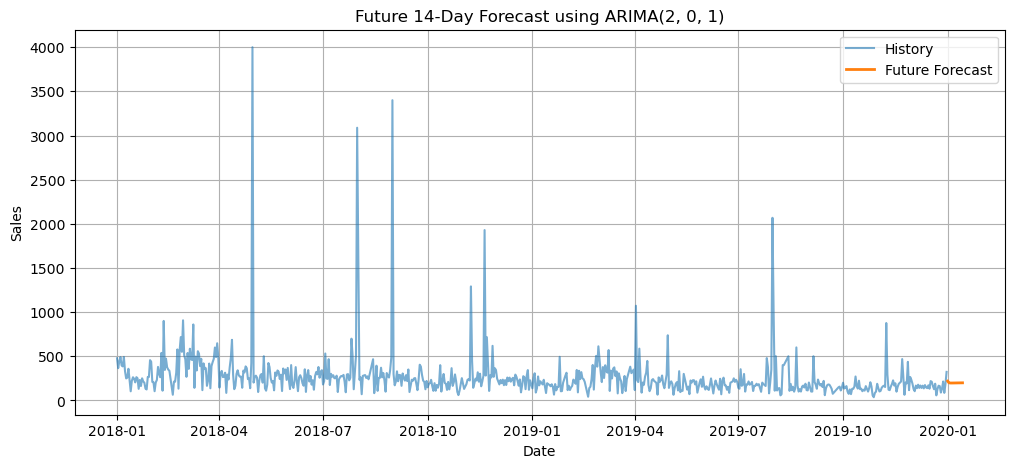

In [17]:

# --------------------------------------------------------
# SECTION 10: Future Forecast (next 14 days)
# --------------------------------------------------------
final_model = ARIMA(ts, order=best_order).fit()

future_steps = 14

future_fcst = final_model.forecast(steps=future_steps)


print(f"\nNext {future_steps} days forecast:")
print(future_fcst.to_frame(name='forecast'))

plt.figure()
plt.plot(ts.index, ts.values, label="History", alpha=0.6)
plt.plot(future_fcst.index, future_fcst.values, label="Future Forecast", linewidth=2)
plt.title(f"Future {future_steps}-Day Forecast using ARIMA{best_order}")
plt.xlabel("Date"); plt.ylabel("Sales")
plt.legend()
plt.show()


In [18]:

# --------------------------------------------------------
# SECTION 11: Summary
# --------------------------------------------------------

print("- We chose 'd' (differencing) by testing stationarity with ADF and picking the smallest d that makes the series stationary.")
print("- AIC balances fit vs complexity: lower AIC is better because it rewards fit but penalizes too many parameters.")
print(f"- ACF shows correlation at lags: {acf_sig[:10]}{' ...' if len(acf_sig)>10 else ''}.")
print(f"- PACF shows partial correlation at lags: {pacf_sig[:10]}{' ...' if len(pacf_sig)>10 else ''}.")
print("- Heuristic: PACF cutoff → AR order (p), ACF cutoff → MA order (q).")
print(f"- We validated (p,q) with a quick grid search and selected ARIMA{best_order} by minimum AIC.")


- We chose 'd' (differencing) by testing stationarity with ADF and picking the smallest d that makes the series stationary.
- AIC balances fit vs complexity: lower AIC is better because it rewards fit but penalizes too many parameters.
- ACF shows correlation at lags: [].
- PACF shows partial correlation at lags: [].
- Heuristic: PACF cutoff → AR order (p), ACF cutoff → MA order (q).
- We validated (p,q) with a quick grid search and selected ARIMA(2, 0, 1) by minimum AIC.
